# HistGradientBoostingClassifier

Datos desde **Join.ipynb** (BLOQUE 6 + exportación):
- `Datos/Trusted/train_balanceado.csv` — entrenamiento 50/50
- `Datos/Trusted/test_modelo.csv` — test (lectura por chunks)

No uses `datos_modelo.csv` completo (7,4M filas).

In [ ]:
# %pip install scikit-learn pandas numpy

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score,
)

RUTA_TRAIN = Path("../Datos/Trusted/train_balanceado.csv")
RUTA_TEST = Path("../Datos/Trusted/test_modelo.csv")
RUTA_META = Path("artifacts/split_meta.json")
RANDOM_STATE = 42
CHUNK_SIZE = 200_000

COLS_EXCLUIR_MODELO = {"target", "TW", "BARRIO", "summary", "summary_agrupado"}

## 1. Cargar train balanceado

In [2]:
def cargar_train_balanceado(ruta_train=RUTA_TRAIN, cols_excluir=COLS_EXCLUIR_MODELO):
    if not Path(ruta_train).exists():
        raise FileNotFoundError(
            f"No existe {ruta_train}. Exporta desde Join.ipynb (BLOQUE 6 + exportación)."
        )
    train = pd.read_csv(ruta_train, parse_dates=["TW"], low_memory=False)
    y = train["target"].astype(int)
    cols_x = [c for c in train.columns if c not in cols_excluir]
    cols_x = [c for c in cols_x if pd.api.types.is_numeric_dtype(train[c])]
    X = train[cols_x].astype(np.float32)
    llaves = train[["TW", "BARRIO"]] if {"TW", "BARRIO"}.issubset(train.columns) else None
    return X, y, cols_x, llaves, train


X_train_bal, y_train_bal, cols_X, llaves_train, df_train = cargar_train_balanceado()

print(f"train_balanceado: {X_train_bal.shape[0]:,} filas x {len(cols_X)} features")
if RUTA_META.exists():
    meta = json.loads(RUTA_META.read_text(encoding="utf-8"))
    print("fecha_corte (Join):", meta.get("fecha_corte"))

display(
    y_train_bal.value_counts()
    .sort_index()
    .to_frame("cantidad")
    .assign(porcentaje=lambda x: (x["cantidad"] / len(y_train_bal) * 100).round(2))
)

train_balanceado: 176,116 filas x 27 features
fecha_corte (Join): 2019-06-11T02:00:00.000000


,cantidad,porcentaje
target,,
0,88058,50.0
1,88058,50.0


## 2. Iterador de test (chunks)

In [3]:
def iter_test_chunks(ruta_test=RUTA_TEST, cols_x=cols_X, chunk_size=CHUNK_SIZE):
    if not Path(ruta_test).exists():
        raise FileNotFoundError(f"No existe {ruta_test}. Exporta test_modelo.csv desde Join.ipynb.")
    reader = pd.read_csv(
        ruta_test,
        parse_dates=["TW"],
        chunksize=chunk_size,
        low_memory=False,
    )
    for chunk in reader:
        y = chunk["target"].astype(int)
        X = chunk[cols_x].astype(np.float32)
        llaves = chunk[["TW", "BARRIO"]] if {"TW", "BARRIO"}.issubset(chunk.columns) else None
        yield X, y, llaves


X_preview, y_preview, _ = next(iter_test_chunks())
print(f"Primer chunk test: X={X_preview.shape}, positivos={int(y_preview.sum())}")

Primer chunk test: X=(200000, 27), positivos=2667


## 3. Entrenar HistGradientBoosting

In [4]:
modelo_hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_depth=None,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    # train ya viene balanceado 50/50 desde Join
)

print("Entrenando HistGradientBoostingClassifier...")
modelo_hgb.fit(X_train_bal, y_train_bal)
print("Iteraciones usadas:", modelo_hgb.n_iter_)
print("Listo.")

Entrenando HistGradientBoostingClassifier...
Iteraciones usadas: 123
Listo.


## 4. Evaluar en test (chunks)

In [5]:
y_true_all = []
y_pred_all = []
y_proba_all = []

print("Prediciendo test por chunks...")
for i, (X_c, y_c, _) in enumerate(iter_test_chunks()):
    y_pred_all.append(modelo_hgb.predict(X_c))
    y_proba_all.append(modelo_hgb.predict_proba(X_c)[:, 1])
    y_true_all.append(y_c.to_numpy())
    if (i + 1) % 5 == 0:
        print(f"  chunk {i + 1}...")

y_test = np.concatenate(y_true_all)
y_pred = np.concatenate(y_pred_all)
y_proba = np.concatenate(y_proba_all)

print(f"\nTest evaluado: {len(y_test):,} filas")
print("=" * 70)
print("HIST GRADIENT BOOSTING — TEST")
print("=" * 70)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"],
))
print(classification_report(y_test, y_pred, zero_division=0))

Prediciendo test por chunks...
  chunk 5...

Test evaluado: 1,458,412 filas
HIST GRADIENT BOOSTING — TEST
Accuracy:  0.6972
Precision: 0.0412
Recall:    0.7640
F1:        0.0782
PR-AUC:    0.0834
ROC-AUC:   0.8109


,Pred 0,Pred 1
Real 0,998114,435781
Real 1,5785,18732


              precision    recall  f1-score   support

           0       0.99      0.70      0.82   1433895
           1       0.04      0.76      0.08     24517

    accuracy                           0.70   1458412
   macro avg       0.52      0.73      0.45   1458412
weighted avg       0.98      0.70      0.81   1458412



,umbral,precision,recall,f1,verdaderos_positivos,falsos_positivos,falsos_negativos,verdaderos_negativos
0,0.05,0.0189,0.9965,0.0371,24430,1268727,87,165168
1,0.10,0.0210,0.9881,0.0411,24225,1129317,292,304578
2,0.15,0.0229,0.9765,0.0447,23940,1023364,577,410531
3,0.20,0.0248,0.9611,0.0484,23564,926339,953,507556
4,0.25,0.0269,0.9415,0.0523,23083,835439,1434,598456
5,0.30,0.0290,0.9176,0.0563,22498,751986,2019,681909
6,0.35,0.0315,0.8875,0.0609,21758,668437,2759,765458
7,0.40,0.0343,0.8537,0.0659,20931,589798,3586,844097
8,0.45,0.0374,0.8104,0.0715,19869,511524,4648,922371
9,0.50,0.0412,0.7640,0.0782,18732,435781,5785,998114


MEJOR UMBRAL HIST GRADIENT BOOSTING SEGÚN F1


,umbral,precision,recall,f1,verdaderos_positivos,falsos_positivos,falsos_negativos,verdaderos_negativos
16,0.85,0.1207,0.2353,0.1596,5770.0,42031.0,18747.0,1391864.0


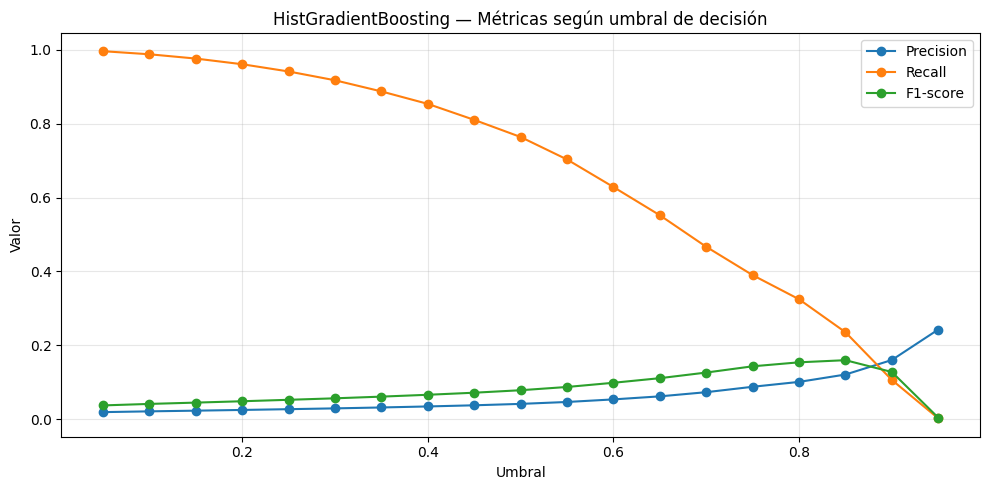

In [6]:
# =========================================================
# CHUNK — AJUSTE DE UMBRAL PARA HIST GRADIENT BOOSTING
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

umbrales = np.arange(0.05, 0.96, 0.05)

resultados_umbrales_hgb = []

for umbral in umbrales:
    y_pred_umbral = (y_proba >= umbral).astype(int)

    precision = precision_score(y_test, y_pred_umbral, zero_division=0)
    recall = recall_score(y_test, y_pred_umbral, zero_division=0)
    f1 = f1_score(y_test, y_pred_umbral, zero_division=0)

    cm = confusion_matrix(y_test, y_pred_umbral)
    tn, fp, fn, tp = cm.ravel()

    resultados_umbrales_hgb.append({
        "umbral": umbral,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "verdaderos_positivos": tp,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_negativos": tn
    })

df_umbrales_hgb = pd.DataFrame(resultados_umbrales_hgb)

display(df_umbrales_hgb.round(4))

mejor_f1_hgb = df_umbrales_hgb.loc[df_umbrales_hgb["f1"].idxmax()]

print("="*70)
print("MEJOR UMBRAL HIST GRADIENT BOOSTING SEGÚN F1")
print("="*70)
display(mejor_f1_hgb.to_frame().T.round(4))

plt.figure(figsize=(10, 5))

plt.plot(df_umbrales_hgb["umbral"], df_umbrales_hgb["precision"], marker="o", label="Precision")
plt.plot(df_umbrales_hgb["umbral"], df_umbrales_hgb["recall"], marker="o", label="Recall")
plt.plot(df_umbrales_hgb["umbral"], df_umbrales_hgb["f1"], marker="o", label="F1-score")

plt.title("HistGradientBoosting — Métricas según umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# =========================================================
# CHUNK — MÉTRICAS FINALES HIST GRADIENT BOOSTING UMBRAL 0.85
# =========================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)

UMBRAL_HGB_FINAL = 0.85

# y_proba debe ser la probabilidad del modelo HistGradientBoosting
y_pred_hgb_final = (y_proba >= UMBRAL_HGB_FINAL).astype(int)

accuracy_hgb = accuracy_score(y_test, y_pred_hgb_final)
precision_hgb = precision_score(y_test, y_pred_hgb_final, zero_division=0)
recall_hgb = recall_score(y_test, y_pred_hgb_final, zero_division=0)
f1_hgb = f1_score(y_test, y_pred_hgb_final, zero_division=0)
pr_auc_hgb = average_precision_score(y_test, y_proba)
roc_auc_hgb = roc_auc_score(y_test, y_proba)

cm_hgb_final = confusion_matrix(y_test, y_pred_hgb_final)
tn, fp, fn, tp = cm_hgb_final.ravel()

metricas_hgb_final = pd.DataFrame([{
    "modelo": "HistGradientBoosting balanceado",
    "umbral": UMBRAL_HGB_FINAL,
    "accuracy": accuracy_hgb,
    "precision": precision_hgb,
    "recall": recall_hgb,
    "f1": f1_hgb,
    "pr_auc": pr_auc_hgb,
    "roc_auc": roc_auc_hgb,
    "tp": tp,
    "fp": fp,
    "fn": fn,
    "tn": tn
}])

display(metricas_hgb_final.round(4))

print("="*70)
print(f"MATRIZ DE CONFUSIÓN — HIST GRADIENT BOOSTING UMBRAL {UMBRAL_HGB_FINAL}")
print("="*70)

display(pd.DataFrame(
    cm_hgb_final,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_hgb_final, zero_division=0))

,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,HistGradientBoosting balanceado,0.85,0.9583,0.1207,0.2353,0.1596,0.0834,0.8109,5770,42031,18747,1391864


MATRIZ DE CONFUSIÓN — HIST GRADIENT BOOSTING UMBRAL 0.85


,Pred 0,Pred 1
Real 0,1391864,42031
Real 1,18747,5770



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98   1433895
           1       0.12      0.24      0.16     24517

    accuracy                           0.96   1458412
   macro avg       0.55      0.60      0.57   1458412
weighted avg       0.97      0.96      0.96   1458412



In [8]:
# =========================================================
# EXPORTAR MÉTRICAS HGB PARA COMPARACIÓN ENTRE NOTEBOOKS
# =========================================================
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

ruta_metricas_hgb = ARTIFACTS_DIR / "metricas_hgb.csv"
metricas_hgb_final.to_csv(ruta_metricas_hgb, index=False)

print(f"Métricas HGB guardadas en: {ruta_metricas_hgb.resolve()}")
display(metricas_hgb_final.round(4))

Métricas HGB guardadas en: C:\Users\camil\OneDrive\Documentos\Aprendizaje de Maquina\Taller\Modelado\artifacts\metricas_hgb.csv


,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,HistGradientBoosting balanceado,0.85,0.9583,0.1207,0.2353,0.1596,0.0834,0.8109,5770,42031,18747,1391864
